In [12]:
pip install xgboost shap optuna

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 425 kB 580 kB/s eta 0:00:01
     |████████████████████████████████| 2.2 MB 13.5 MB/s eta 0:00:01
     |████████████████████████████████| 247 kB 23.5 MB/s eta 0:00:01
     |████████████████████████████████| 78 kB 21.3 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("📂 Loading Extracted Features...")
X = np.load('features.npy')
y = np.load('labels.npy')

# ─────────────────────────────────────────────────────────
# 1. THE HELD-OUT TEST SET (Fixing Data Leakage)
# ─────────────────────────────────────────────────────────
# We split off 20% of the data strictly for final evaluation.
# 'stratify=y' ensures all 8 classes are proportionately represented.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Held-out Test set: {X_test.shape[0]} samples")

/Users/rooneysingh0027/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📂 Loading Extracted Features...
Training set: 1440 samples
Held-out Test set: 360 samples


## GRIDSEARCH CV

In [4]:
# 3. Define the Grid for Fine-Tuning
# We focus on depth and learning rate to control the "boosting" speed
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 6],
    'learning_rate': [0.05, 0.1, 0.2]
}

# 4. Stratified Grid Search
# This keeps the class distribution (NRV, Bearing, etc.) consistent per fold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(xgb_clf, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)

print("🚀 Starting XGBoost training...")
grid.fit(X, y)

print(f"✅ Best Accuracy: {grid.best_score_:.2%}")
best_model = grid.best_estimator_

🚀 Starting XGBoost training...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
✅ Best Accuracy: 97.89%


## OPTUNA SEARCH

In [2]:
def objective(trial):
    param = {
        'objective': 'multi:softprob',
        'num_class': 8,
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0,

        'n_estimators': 500,          # lower ceiling — early stopping still trims this down
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.2, log=True),  # raised floor from 0.01
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'early_stopping_rounds': 20,   # tighter patience
    }

    # Single 3-fold during search — not repeated 5x2. Save the 10-fold rigor for the final model.
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_cv_train, X_cv_val = X_train[train_idx], X_train[val_idx]
        y_cv_train, y_cv_val = y_train[train_idx], y_train[val_idx]

        model = xgb.XGBClassifier(**param)
        model.fit(X_cv_train, y_cv_train, eval_set=[(X_cv_val, y_cv_val)], verbose=False)

        preds = model.predict(X_cv_val)
        acc = accuracy_score(y_cv_val, preds)
        cv_scores.append(acc)

        # Report intermediate value so the pruner can kill bad trials mid-CV
        trial.report(np.mean(cv_scores), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(cv_scores)

study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1)  # kills trials that are already losing after fold 1
)
print("\n🚀 Initiating Optuna Bayesian Optimization...")
study.optimize(objective, n_trials=100, timeout=1800, show_progress_bar=True)  # hard 30-min cap as a safety net

[I 2026-06-28 23:08:28,793] A new study created in memory with name: no-name-f55fe114-8eb4-4e2e-ba57-ceb83fa1dd70



🚀 Initiating Optuna Bayesian Optimization...


Best trial: 0. Best value: 0.965278:   1%|          | 1/100 [00:12<20:47, 12.60s/it, 12.60/1800 seconds]

[I 2026-06-28 23:08:41,410] Trial 0 finished with value: 0.9652777777777777 and parameters: {'max_depth': 3, 'learning_rate': 0.05114752468308781, 'subsample': 0.8209500646491981, 'colsample_bytree': 0.8223709673598678, 'min_child_weight': 9, 'gamma': 1.3027113477788403e-08, 'reg_alpha': 0.04735849440234929, 'reg_lambda': 1.0776245694991938e-05}. Best is trial 0 with value: 0.9652777777777777.


Best trial: 0. Best value: 0.965278:   2%|▏         | 2/100 [00:17<13:00,  7.96s/it, 17.31/1800 seconds]

...

[I 2026-06-28 23:29:29,512] Trial 97 finished with value: 0.9763888888888889 and parameters: {'max_depth': 6, 'learning_rate': 0.03445330042319737, 'subsample': 0.5742575488533044, 'colsample_bytree': 0.8403240691184763, 'min_child_weight': 3, 'gamma': 0.006757265382596123, 'reg_alpha': 0.052013341795266524, 'reg_lambda': 0.01341786061919109}. Best is trial 63 with value: 0.9798611111111111.


Best trial: 63. Best value: 0.979861:  99%|█████████▉| 99/100 [21:12<00:14, 14.86s/it, 1272.67/1800 seconds]

[I 2026-06-28 23:29:41,474] Trial 98 finished with value: 0.9777777777777779 and parameters: {'max_depth': 5, 'learning_rate': 0.07151094410949387, 'subsample': 0.53178959176886, 'colsample_bytree': 0.7852484673549893, 'min_child_weight': 1, 'gamma': 0.0003088573207542973, 'reg_alpha': 0.008218393773893738, 'reg_lambda': 0.588455082892681}. Best is trial 63 with value: 0.9798611111111111.


Best trial: 63. Best value: 0.979861: 100%|██████████| 100/100 [21:20<00:00, 12.80s/it, 1280.42/1800 seconds]

[I 2026-06-28 23:29:49,228] Trial 99 pruned. 


## EVALUATION

In [3]:
# ─────────────────────────────────────────────────────────
# 4. TRAIN FINAL MODEL ON FULL TRAINING DATA
# ─────────────────────────────────────────────────────────
# We extract the best params, add back the fixed params
best_params = study.best_trial.params
best_params.update({
    'objective': 'multi:softprob',
    'num_class': 8,
    'tree_method': 'hist',
    'random_state': 42,
    'n_jobs': -1,
    'n_estimators': 2000, 
    'early_stopping_rounds': 50
})

# To use early stopping on the final fit, we carve out a small eval set from the training data
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_val_final, y_val_final)],
    verbose=False
)

print(f"\n🌲 Final model stopped at tree {final_model.best_iteration}")

# ─────────────────────────────────────────────────────────
# 5. UNBIASED TEST EVALUATION (NO LEAKAGE)
# ─────────────────────────────────────────────────────────
print("\n🔍 Evaluating Final Model on Held-Out Test Set...")
test_preds = final_model.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)

print(f"🎯 UNBIASED TEST ACCURACY: {test_acc * 100:.2f}%")
print("\nClassification Report:")
fault_names = ['Healthy', 'LIV', 'LOV', 'NRV', 'Bearing', 'Piston', 'Riderbelt', 'Flywheel']
print(classification_report(y_test, test_preds, target_names=fault_names))


🌲 Final model stopped at tree 736

🔍 Evaluating Final Model on Held-Out Test Set...
🎯 UNBIASED TEST ACCURACY: 98.33%

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        45
         LIV       0.94      1.00      0.97        45
         LOV       1.00      0.98      0.99        45
         NRV       1.00      0.96      0.98        45
     Bearing       0.98      1.00      0.99        45
      Piston       1.00      0.96      0.98        45
   Riderbelt       1.00      0.98      0.99        45
    Flywheel       0.96      1.00      0.98        45

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



## VISUALISATIONS

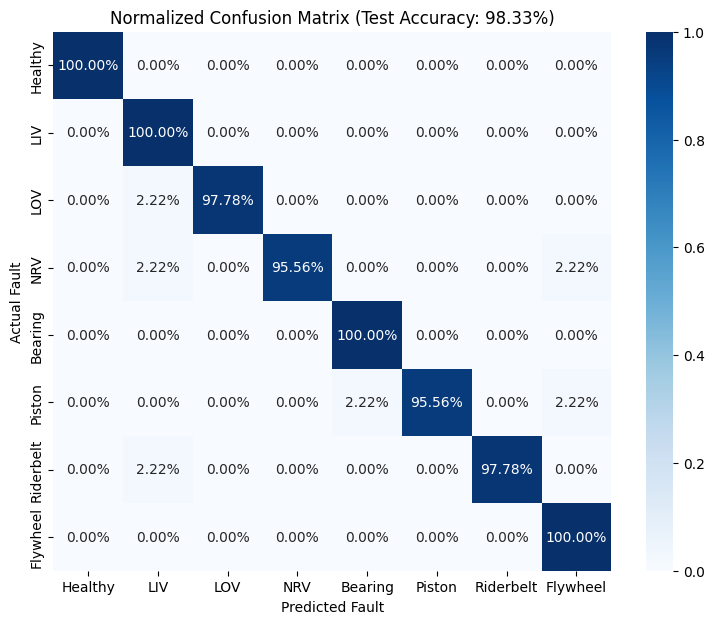

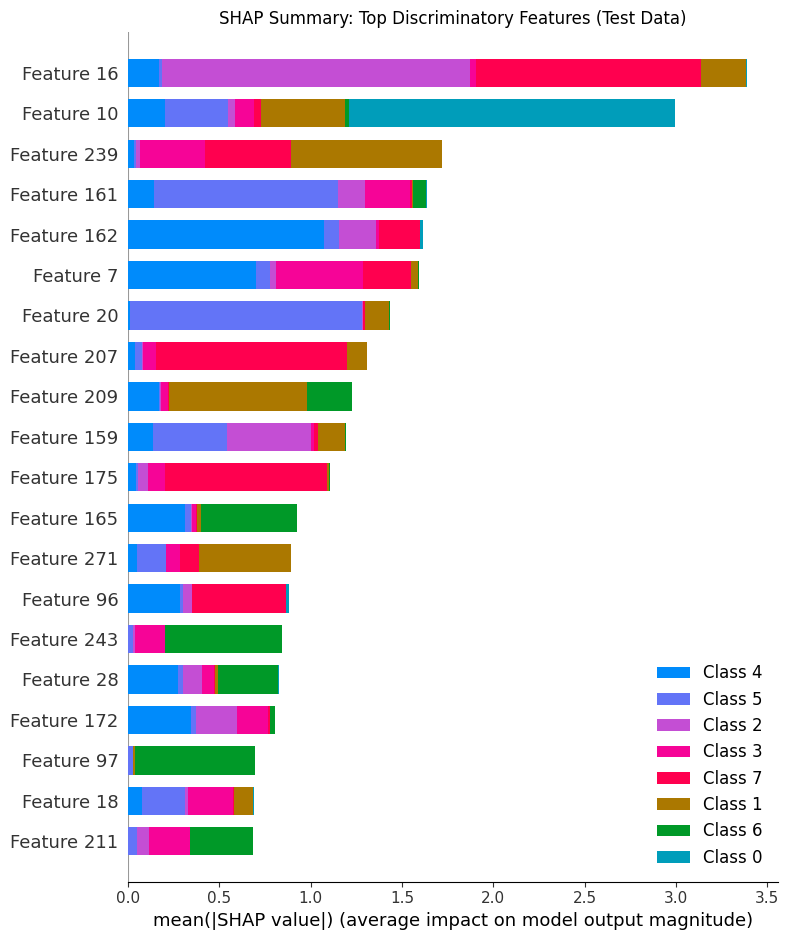

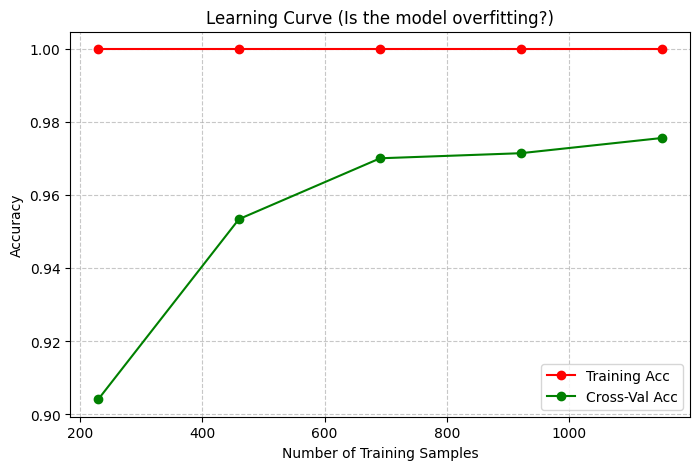

In [4]:
import shap
from sklearn.model_selection import learning_curve

# ── 1. Normalized Confusion Matrix (On Test Set) ──
cm = confusion_matrix(y_test, test_preds, normalize='true')
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=fault_names, yticklabels=fault_names)
plt.title(f"Normalized Confusion Matrix (Test Accuracy: {test_acc * 100:.2f}%)")
plt.xlabel("Predicted Fault")
plt.ylabel("Actual Fault")
plt.show()

# ── 2. SHAP Values (On Test Set) ──
# We explicitly pass X_test so the explainer evaluates what drives unseen data
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
plt.title("SHAP Summary: Top Discriminatory Features (Test Data)")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.show()

# ── 3. Learning Curve (On Training Set ONLY) ──
# We pass only X_train and y_train here. 
# sklearn will internally cross-validate it, ensuring X_test remains unseen.
# We remove early stopping for the learning curve to avoid API conflicts with sklearn.
lc_params = best_params.copy()
lc_params.pop('early_stopping_rounds') 
lc_params['n_estimators'] = final_model.best_iteration  # Use the tree count found above
lc_model = xgb.XGBClassifier(**lc_params)

train_sizes, train_scores, cv_scores = learning_curve(
    lc_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.2, 1.0, 5)
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='r', label='Training Acc')
plt.plot(train_sizes, np.mean(cv_scores, axis=1), 'o-', color='g', label='Cross-Val Acc')
plt.title("Learning Curve (Is the model overfitting?)")
plt.xlabel("Number of Training Samples")
plt.ylabel("Accuracy")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc="best")
plt.show()

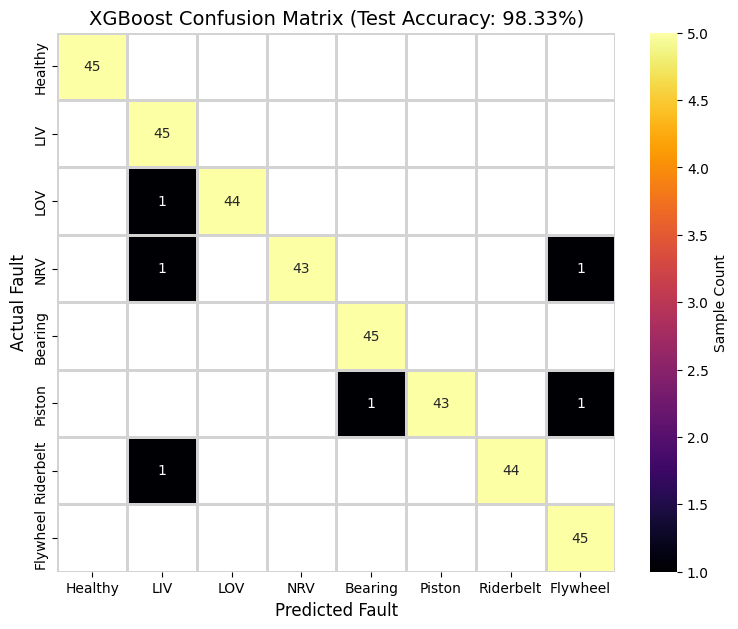

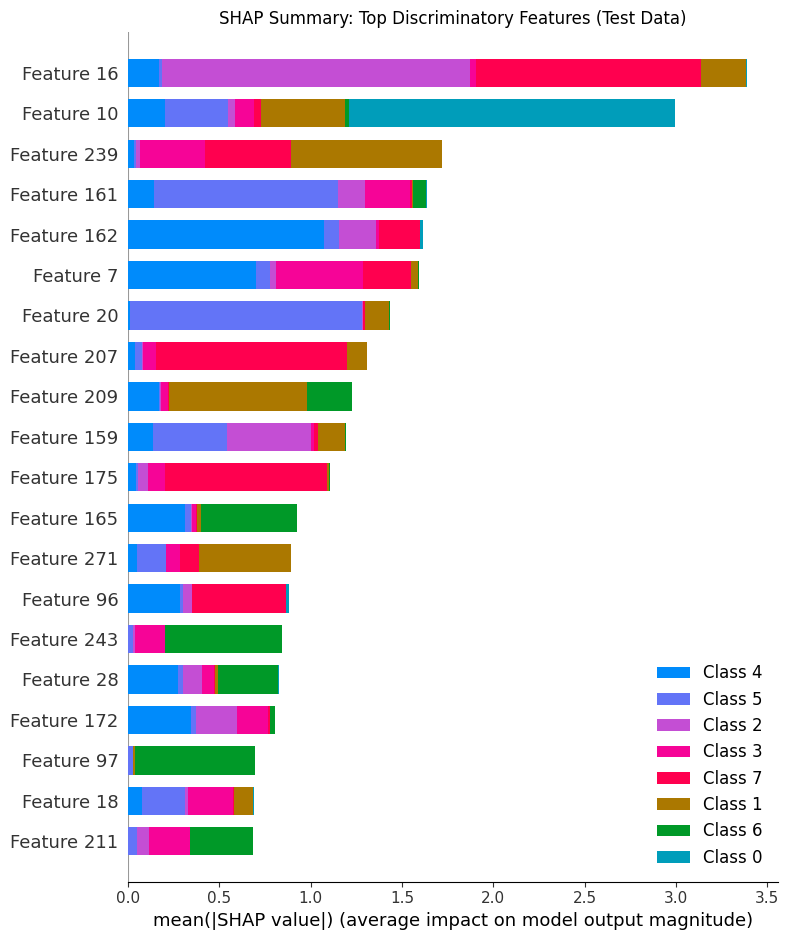

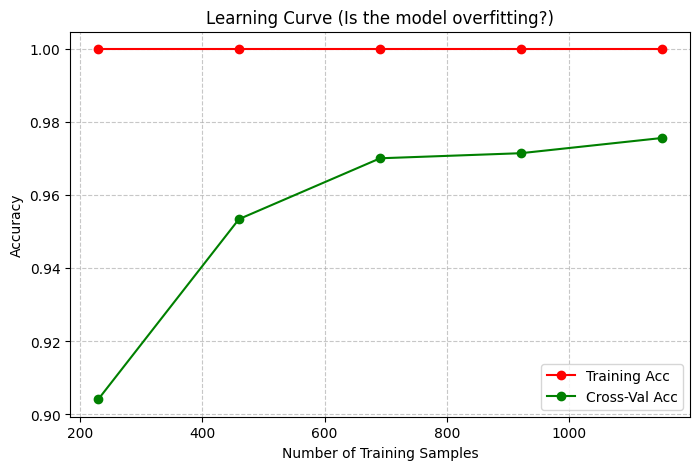

In [8]:
import shap
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. XGBoost Confusion Matrix — Error Focus (Raw Counts) ──

# 1. Get RAW counts
cm_xgb = confusion_matrix(y_test, test_preds)

# 2. Find the maximum ERROR count to cap the color scale.
# We temporarily zero out the diagonal on a copy just to find the max error value
cm_off_diag = cm_xgb.copy()
np.fill_diagonal(cm_off_diag, 0)
max_error_count = cm_off_diag.max()

# Cap the color scale at max_error_count (or 5 minimum) so errors stand out.
vmax_val = max(max_error_count, 5)

# 3. Create a mask to completely hide any cell that has a 0 (reduces clutter)
mask = cm_xgb == 0

plt.figure(figsize=(9, 7))

# Plot with the custom vmax. The diagonal will be max color, 0s will be blank, 
# and the errors will be clearly shaded based on their severity.
# Using 'Blues' to keep XGBoost visually distinct from the SVM plots.
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='inferno', mask=mask,
            vmax=vmax_val,
            xticklabels=fault_names, yticklabels=fault_names,
            linewidths=1, linecolor='lightgray',
            cbar_kws={'label': 'Sample Count'})

plt.title(f"XGBoost Confusion Matrix (Test Accuracy: {test_acc * 100:.2f}%)", fontsize=14)
plt.xlabel("Predicted Fault", fontsize=12)
plt.ylabel("Actual Fault", fontsize=12)
plt.show()

# ── 2. SHAP Values (On Test Set) ──
# We explicitly pass X_test so the explainer evaluates what drives unseen data
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
plt.title("SHAP Summary: Top Discriminatory Features (Test Data)")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.show()

# ── 3. Learning Curve (On Training Set ONLY) ──
# We pass only X_train and y_train here. 
# sklearn will internally cross-validate it, ensuring X_test remains unseen.
# We remove early stopping for the learning curve to avoid API conflicts with sklearn.
lc_params = best_params.copy()
lc_params.pop('early_stopping_rounds') 
lc_params['n_estimators'] = final_model.best_iteration  # Use the tree count found above
lc_model = xgb.XGBClassifier(**lc_params)

train_sizes, train_scores, cv_scores = learning_curve(
    lc_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.2, 1.0, 5)
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='r', label='Training Acc')
plt.plot(train_sizes, np.mean(cv_scores, axis=1), 'o-', color='g', label='Cross-Val Acc')
plt.title("Learning Curve (Is the model overfitting?)")
plt.xlabel("Number of Training Samples")
plt.ylabel("Accuracy")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc="best")
plt.show()

In [5]:
# ─────────────────────────────────────────────────────────
# Save XGBoost test-set probabilities for cross-notebook ensembling
# ─────────────────────────────────────────────────────────
import numpy as np

xgb_test_probs = final_model.predict_proba(X_test)

np.save('xgb_test_probs.npy', xgb_test_probs)
np.save('xgb_y_test.npy', y_test)
print(f"✅ Saved XGBoost probabilities: shape {xgb_test_probs.shape}")

✅ Saved XGBoost probabilities: shape (360, 8)


In [6]:
import numpy as np
from sklearn.model_selection import StratifiedKFold

N_FOLDS = 5
oof_skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=2024)  # IDENTICAL seed to SVM notebook

xgb_oof_probs = np.zeros((X_train.shape[0], 8))

for fold_idx, (tr_idx, val_idx) in enumerate(oof_skf.split(X_train, y_train)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    fold_params = best_params.copy()
    fold_model = xgb.XGBClassifier(**fold_params)
    fold_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    xgb_oof_probs[val_idx] = fold_model.predict_proba(X_val)
    print(f"  Fold {fold_idx+1}/{N_FOLDS} done")

# final_model is already trained on the full X_train from your earlier cell
xgb_test_probs = final_model.predict_proba(X_test)

np.save('xgb_oof_probs.npy', xgb_oof_probs)
np.save('xgb_test_probs.npy', xgb_test_probs)
print("✅ Saved XGBoost OOF + test probabilities for stacking")

  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done
✅ Saved XGBoost OOF + test probabilities for stacking
